# SAME en dependencias penitenciarias y policiales de CABA
### Storytelling de los hallazgos

4.056 intervenciones del SAME en comisarías y alcaidías de la Ciudad de Buenos Aires
(**01/2022–05/2026**), obtenidas por un pedido de acceso a la información pública
(Ley 104). El Estado las entregó como un **PDF de 317 páginas**; las convertimos en un
dataset consultable, anonimizado, geocodificado y enriquecido (24 variables por LLM +
comuna + NBI). Detalle metodológico en [`plan-analisis.md`](../docs/plan-analisis.md).

**Cómo leer estos datos — 3 advertencias:**
1. No es "salud en CABA": es la salud de quienes pasan por la custodia, y la población
   es **mixta** (detenidos, civiles, personal policial).
2. Hay **numeradores, no denominadores** (no sabemos sobre cuánta población) → se cuenta,
   no se calculan tasas por persona.
3. Todo es **asociacional, no causal**; las variables de texto son best-effort de un LLM.

In [1]:
# Setup: conexión, datos base y estilo.
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv

ROOT = next((d for d in [Path.cwd(), *Path.cwd().parents] if (d / ".env").exists()), Path.cwd())
load_dotenv(ROOT / ".env")  # carga el .env del repo

from same.db import connect  # noqa: E402

plt.rcParams.update(
    {
        "figure.dpi": 110,
        "font.size": 11,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "axes.titleweight": "bold",
    }
)
AZUL, ROJO, GRIS, VERDE, NARANJA = "#1f77b4", "#d62728", "#7f7f7f", "#2ca02c", "#ff7f0e"
W = 0.36

_SQL = """
SELECT v.fecha_hora, v.tipo_sujeto, v.sexo, v.trasladado, v.codigo_prioridad,
       v.diagnostico, v.comuna, v.tipo_dependencia,
       (a.atributos->>'agresion_por_terceros')::boolean      ag,
       (a.atributos->>'motin_o_conflicto_colectivo')::boolean mo,
       (a.atributos->>'crisis_psiquiatrica')::boolean         cr,
       (a.atributos->>'condicion_cronica')::boolean           cro,
       (a.atributos->>'embarazo')::boolean                    emb
FROM v_intervenciones v JOIN intervencion_analisis a ON a.intervencion_id = v.id
"""
with connect() as conn, conn.cursor() as cur:
    cur.execute(_SQL)
    df = pd.DataFrame(cur.fetchall(), columns=[c[0] for c in cur.description])
for _c in ["trasladado", "ag", "mo", "cr", "cro", "emb"]:
    df[_c] = df[_c].fillna(False).astype(bool)
df["fecha_hora"] = pd.to_datetime(df.fecha_hora)
df["rojo"] = df.codigo_prioridad.fillna("").str.match(r"[14] ")
print(f"{len(df)} intervenciones, {df.fecha_hora.min():%Y-%m} a {df.fecha_hora.max():%Y-%m}")

4056 intervenciones, 2022-01 a 2026-05


## 1. No son solo detenidos: la comisaría como acceso de salud mental

El paciente es **detenido en 59%**, pero **civil en 16,5%** y **personal policial en 5%**.
Los civiles que llegan a la comisaría son sobre todo **víctimas de agresión (25%)** y
**gente en crisis psiquiátrica (11%)** — la dependencia funciona como punto de acceso de
salud mental de último recurso. El personal aparece como víctima de lesiones.

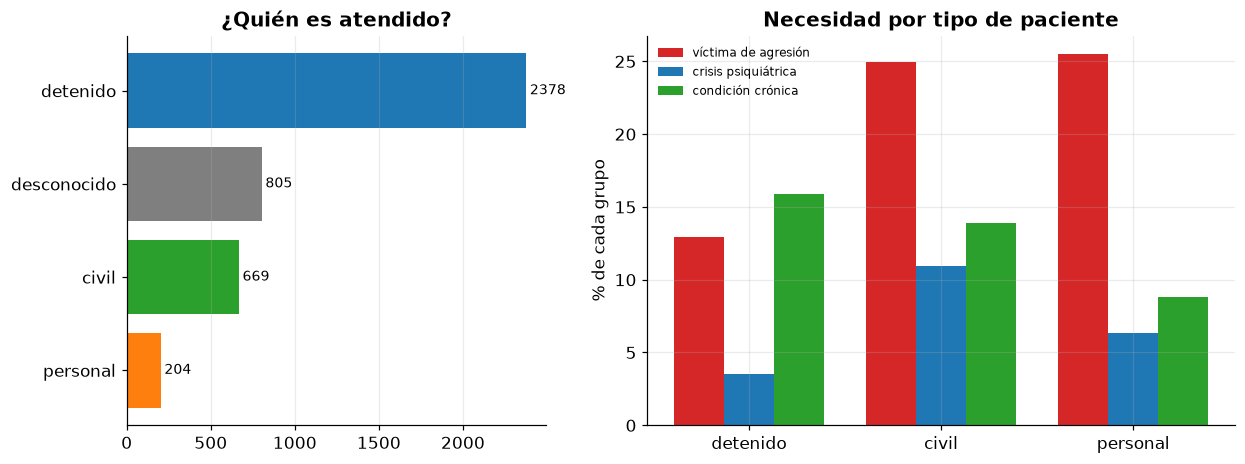

In [2]:
sub = df[df.tipo_sujeto.isin(["detenido", "civil", "personal_policial"])]
needs = (sub.groupby("tipo_sujeto")[["ag", "cr", "cro"]].mean() * 100).reindex(
    ["detenido", "civil", "personal_policial"]
)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.6), gridspec_kw={"width_ratios": [1, 1.4]})
dist = df.tipo_sujeto.value_counts()
keys = ["personal_policial", "civil", "desconocido", "detenido"]
a1.barh(
    ["personal", "civil", "desconocido", "detenido"],
    [dist.get(k, 0) for k in keys],
    color=[NARANJA, VERDE, GRIS, AZUL],
)
for i, v in enumerate([dist.get(k, 0) for k in keys]):
    a1.text(v + 20, i, f"{v}", va="center", fontsize=9)
a1.set_title("¿Quién es atendido?")
a1.grid(axis="y")
x = np.arange(3)
for i, (c, lab, col) in enumerate(
    [
        ("ag", "víctima de agresión", ROJO),
        ("cr", "crisis psiquiátrica", AZUL),
        ("cro", "condición crónica", VERDE),
    ]
):
    a2.bar(x + (i - 1) * 0.26, needs[c].values, 0.26, label=lab, color=col)
a2.set_xticks(x)
a2.set_xticklabels(["detenido", "civil", "personal"])
a2.set_ylabel("% de cada grupo")
a2.set_title("Necesidad por tipo de paciente")
a2.legend(fontsize=8, frameon=False)
plt.show()

## 2. 🎯 Una brecha de género en el traslado al hospital

A primera vista no hay brecha (traslado M 24% vs F 23%). Pero el **embarazo** infla el
traslado de las mujeres. Al controlar embarazo, gravedad y diagnóstico, las **mujeres se
trasladan ~38% menos** (OR 0,62, p=0,004). Y lo más fuerte: **las codifican más críticas**
(ROJO 67% vs 60%) **pero las trasladan menos**. Dentro de los ROJO: F 24% vs M 32%
(p=0,009). Concentrado en lo **cardiovascular** (F 27% vs M 61%) — eco del subtratamiento
cardíaco femenino documentado. Observacional, con subgrupos chicos: señal fuerte, no prueba.

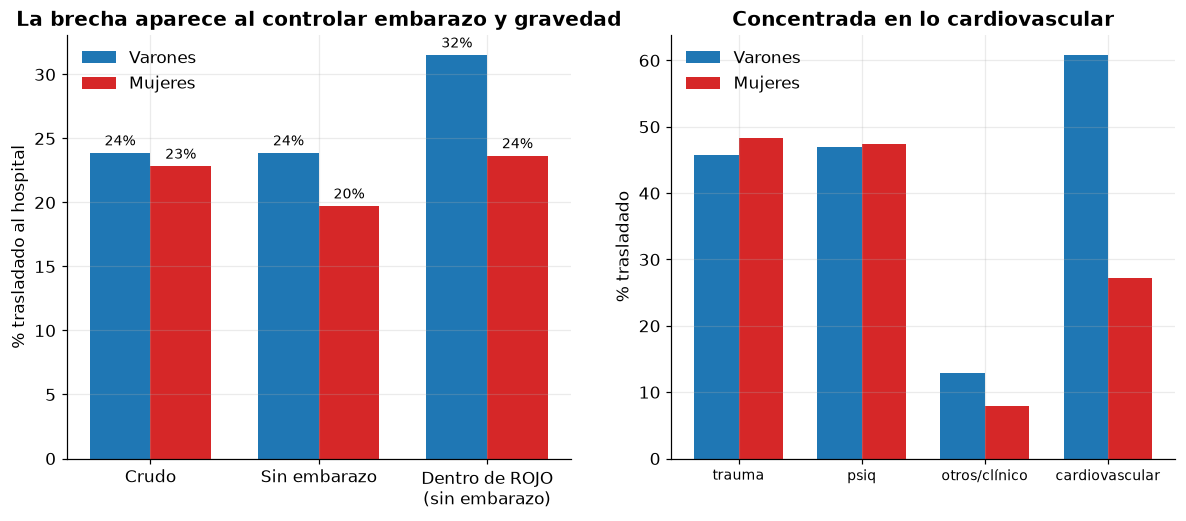

In [3]:
mf = df[df.sexo.isin(["M", "F"])].copy()
code = df.diagnostico.fillna("00").str[:2]
grp = {
    "01": "trauma",
    "03": "trauma",
    "04": "trauma",
    "08": "trauma",
    "18": "psiq",
    "10": "cardiovascular",
    "11": "resp",
    "15": "neuro",
}
mf["dxg"] = code.loc[mf.index].map(grp).fillna("otros/clínico")


def _tr(d, s):
    dd = d[d.sexo == s]
    return 100 * dd.trasladado.mean() if len(dd) else 0


scen = [
    ("Crudo", mf),
    ("Sin embarazo", mf[~mf.emb]),
    ("Dentro de ROJO\n(sin embarazo)", mf[mf.rojo & ~mf.emb]),
]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 5))
x = np.arange(len(scen))
a1.bar(x - W / 2, [_tr(d, "M") for _, d in scen], W, label="Varones", color=AZUL)
a1.bar(x + W / 2, [_tr(d, "F") for _, d in scen], W, label="Mujeres", color=ROJO)
for i, (_, d) in enumerate(scen):
    a1.text(i - W / 2, _tr(d, "M") + 0.6, f"{_tr(d, 'M'):.0f}%", ha="center", fontsize=9)
    a1.text(i + W / 2, _tr(d, "F") + 0.6, f"{_tr(d, 'F'):.0f}%", ha="center", fontsize=9)
a1.set_xticks(x)
a1.set_xticklabels([s for s, _ in scen])
a1.set_ylabel("% trasladado al hospital")
a1.set_title("La brecha aparece al controlar embarazo y gravedad")
a1.legend(frameon=False)
order = ["trauma", "psiq", "otros/clínico", "cardiovascular"]
gg = (mf[~mf.emb].groupby(["dxg", "sexo"]).trasladado.mean().unstack() * 100).reindex(order)
xx = np.arange(len(order))
a2.bar(xx - W / 2, gg["M"].values, W, label="Varones", color=AZUL)
a2.bar(xx + W / 2, gg["F"].values, W, label="Mujeres", color=ROJO)
a2.set_xticks(xx)
a2.set_xticklabels(order, fontsize=9)
a2.set_ylabel("% trasladado")
a2.set_title("Concentrada en lo cardiovascular")
a2.legend(frameon=False)
plt.show()

## 3. Violencia en 1 de cada 6 intervenciones

**Personal y civiles son víctimas de agresión al 25%** (el doble que los detenidos). Por
setting: **alcaidías → motines** (conflicto colectivo, detención prolongada);
**comisarías → agresión individual**. 1 de cada 7 agresiones es con arma blanca.

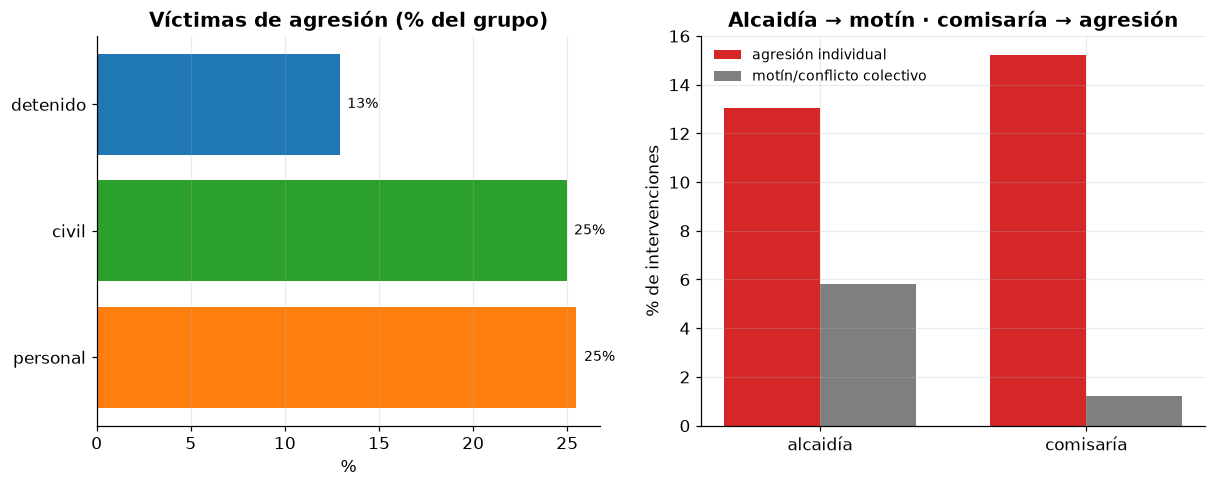

In [4]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.6))
vic = (sub.groupby("tipo_sujeto").ag.mean() * 100).reindex(
    ["personal_policial", "civil", "detenido"]
)
a1.barh(["personal", "civil", "detenido"], vic.values, color=[NARANJA, VERDE, AZUL])
for i, v in enumerate(vic.values):
    a1.text(v + 0.4, i, f"{v:.0f}%", va="center", fontsize=9)
a1.set_title("Víctimas de agresión (% del grupo)")
a1.set_xlabel("%")
a1.grid(axis="y")
setg = (
    df[df.tipo_dependencia.isin(["alcaidia", "comisaria"])]
    .groupby("tipo_dependencia")[["ag", "mo"]]
    .mean()
    * 100
).reindex(["alcaidia", "comisaria"])
xx = np.arange(2)
a2.bar(xx - W / 2, setg["ag"].values, W, label="agresión individual", color=ROJO)
a2.bar(xx + W / 2, setg["mo"].values, W, label="motín/conflicto colectivo", color=GRIS)
a2.set_xticks(xx)
a2.set_xticklabels(["alcaidía", "comisaría"])
a2.set_ylabel("% de intervenciones")
a2.set_title("Alcaidía → motín · comisaría → agresión")
a2.legend(frameon=False, fontsize=9)
plt.show()

## 4. Geografía: la detención se concentra en las comunas pobres

El **volumen de intervenciones correlaciona con la pobreza de la comuna** (NBI, r=+0,57,
p=0,026). La **violencia, en cambio, no tiene gradiente socioeconómico barrial**. Abajo:
el mapa de puntos por tipo de dependencia, el choropleth por comuna, y el cruce con NBI.

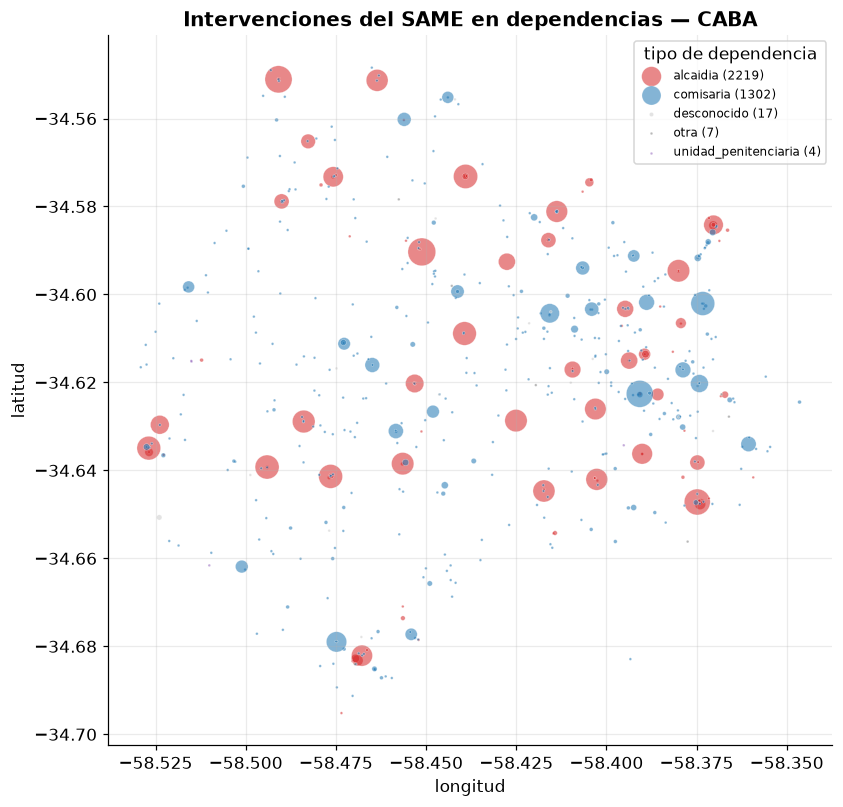

In [5]:
# Mapa de puntos (tamaño ∝ nº de intervenciones por ubicación).
_MAP = """
SELECT u.lat, u.lon, count(*) n,
   mode() WITHIN GROUP (ORDER BY a.atributos->>'tipo_dependencia') tipo
FROM intervenciones i JOIN ubicaciones u ON u.id=i.ubicacion_id
JOIN intervencion_analisis a ON a.intervencion_id=i.id
WHERE u.geom IS NOT NULL GROUP BY u.lat, u.lon
"""
with connect() as conn, conn.cursor() as cur:
    cur.execute(_MAP)
    pts = pd.DataFrame(cur.fetchall(), columns=["lat", "lon", "n", "tipo"])
cmap = {
    "alcaidia": ROJO,
    "comisaria": AZUL,
    "unidad_penitenciaria": "#9467bd",
    "otra": GRIS,
    "desconocido": "#cccccc",
}
fig, ax = plt.subplots(figsize=(8.5, 8.5))
for t, s in pts.groupby("tipo"):
    ax.scatter(
        s.lon,
        s.lat,
        s=s.n * 3,
        alpha=0.55,
        c=cmap.get(t, "#999"),
        edgecolors="white",
        linewidths=0.3,
        label=f"{t} ({int(s.n.sum())})",
    )
ax.set_aspect(1 / 0.82)
ax.set_title("Intervenciones del SAME en dependencias — CABA")
ax.set_xlabel("longitud")
ax.set_ylabel("latitud")
ax.legend(title="tipo de dependencia", fontsize=8)
plt.show()

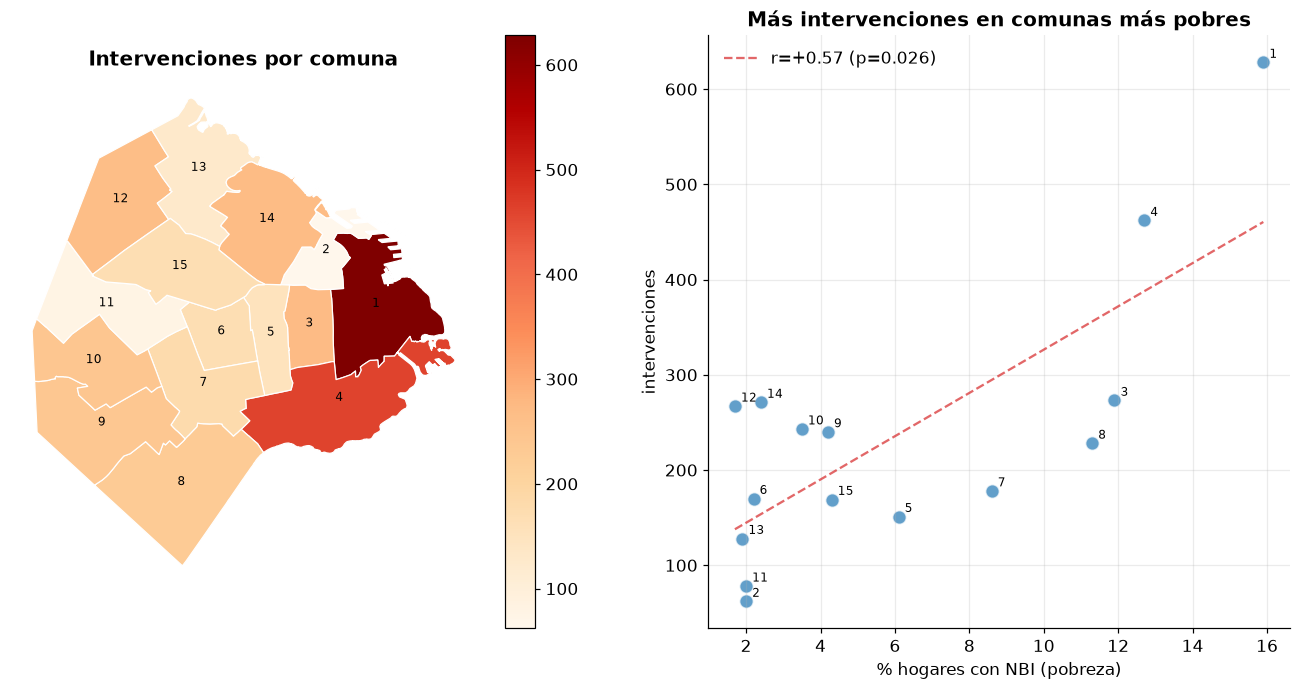

In [6]:
# Choropleth + cruce con NBI por comuna.
import io  # noqa: E402
import urllib.request  # noqa: E402

import geopandas as gpd  # noqa: E402

_NBI = (
    "https://cdn.buenosaires.gob.ar/datosabiertos/datasets/instituto-de-vivienda/"
    "hogares-situacion-vulnerabilidad/NBI-por-comuna.csv"
)
_req = urllib.request.Request(_NBI, headers={"User-Agent": "same/0.1"})
nbi = pd.read_csv(io.BytesIO(urllib.request.urlopen(_req, timeout=30).read()), encoding="latin-1")
nbi = nbi[nbi.Comuna != "total"]
nbi = pd.DataFrame({"comuna": nbi.Comuna.astype(int), "nbi": nbi["Hogares con NBI"].astype(float)})

with connect() as conn, conn.cursor() as cur:
    cur.execute(
        "SELECT comuna, count(*) n FROM intervenciones i "
        "JOIN ubicaciones u ON u.id=i.ubicacion_id WHERE u.comuna IS NOT NULL "
        "GROUP BY u.comuna"
    )
    vol = pd.DataFrame(cur.fetchall(), columns=["comuna", "n"])

_geojson = ROOT / "data/cache/comunas_caba.geojson"
if not _geojson.exists():  # lo baja si no está cacheado (BA Data)
    _url = (
        "https://cdn.buenosaires.gob.ar/datosabiertos/datasets/ministerio-de-educacion/"
        "comunas/comunas.geojson"
    )
    _geojson.parent.mkdir(parents=True, exist_ok=True)
    _geojson.write_bytes(
        urllib.request.urlopen(
            urllib.request.Request(_url, headers={"User-Agent": "same/0.1"}), timeout=30
        ).read()
    )
gdf = gpd.read_file(_geojson)[["comuna", "geometry"]]
gdf["comuna"] = gdf.comuna.astype(float).astype(int)
gdf = gdf.merge(vol, on="comuna", how="left")
mm = vol.merge(nbi, on="comuna").astype(float)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 7))
gdf.plot(column="n", ax=a1, cmap="OrRd", edgecolor="white", linewidth=0.8, legend=True)
for _, r in gdf.iterrows():
    c = r.geometry.centroid
    a1.annotate(f"{int(r.comuna)}", (c.x, c.y), ha="center", fontsize=8)
a1.set_title("Intervenciones por comuna")
a1.axis("off")
a2.scatter(mm.nbi, mm.n, s=80, color=AZUL, alpha=0.7, edgecolors="white")
for _, r in mm.iterrows():
    a2.annotate(int(r.comuna), (r.nbi, r.n), fontsize=8, xytext=(4, 3), textcoords="offset points")
z = np.polyfit(mm.nbi, mm.n, 1)
xs = np.linspace(mm.nbi.min(), mm.nbi.max(), 50)
a2.plot(xs, np.polyval(z, xs), "--", color=ROJO, alpha=0.7, label="r=+0.57 (p=0.026)")
a2.set_xlabel("% hogares con NBI (pobreza)")
a2.set_ylabel("intervenciones")
a2.set_title("Más intervenciones en comunas más pobres")
a2.legend(frameon=False)
a2.grid(alpha=0.25)
plt.show()

## 5. Un sistema que se triplicó

Las intervenciones pasaron de ~45/mes (2022) a ~140/mes (2026) — probablemente la
expansión del sistema de alcaidías de CABA / mejor registro, no necesariamente más
morbilidad (otra vez, el denominador).

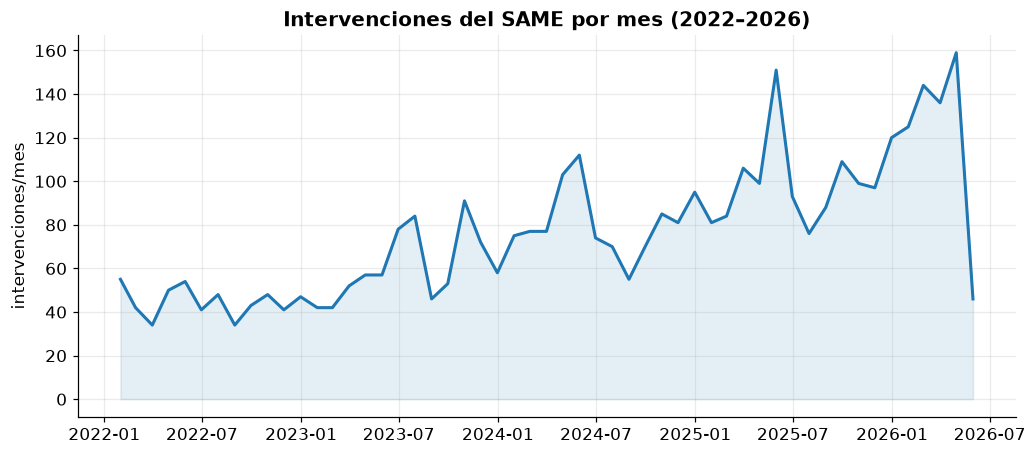

In [7]:
g = df.set_index("fecha_hora").resample("ME").size()
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(g.index, g.values, color=AZUL, lw=2)
ax.fill_between(g.index, g.values, alpha=0.12, color=AZUL)
ax.set_title("Intervenciones del SAME por mes (2022–2026)")
ax.set_ylabel("intervenciones/mes")
plt.show()

## Lo que queda fuera del relato visual (decisión editorial)

La **autolesión, el intento de suicidio y la ingesta de cuerpo extraño** se analizan
internamente pero **no van al storytelling público**: por lo gráfico y por el riesgo de
**contagio/incentivo** (efecto Werther). Hay un patrón fuerte (concentración en detención
prolongada, nocturno, traslado por encima de la gravedad), pero no se publica con detalle.

## Limitaciones

Sin denominador → conteos, no tasas · sexo "desconocido" en 36% · sin outcomes
(mortalidad, tiempos) · sin linkage de persona (removido por privacidad) · `traslado`
subregistrado · variables LLM best-effort. El dato faltante #1 son los **denominadores**
(población alojada por dependencia y período).